# Analisis Exploratorio de Datos — Segmentacion Semantica

Este notebook realiza un analisis exploratorio del dataset de segmentacion semantica
para deteccion de danos en vehiculos. A diferencia de la segmentacion por instancias
(donde cada objeto tiene un ID unico), aqui cada pixel se etiqueta segun la clase de
dano a la que pertenece, sin distinguir instancias individuales.

Dataset: `car_damage_detection/data/car-damages-ready/semantic/`

### Clases
| ID | Nombre         |
|----|----------------|
| 0  | Dent           |
| 1  | Scratch        |
| 2  | No Damage      |
| 3  | Severe Damage  |

## Configuracion e imports

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from glob import glob
from collections import defaultdict, Counter
from PIL import Image
from skimage import measure

plt.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

CLASS_NAMES = {0: 'Background', 1: 'Dent', 2: 'Scratch', 3: 'No Damage', 4: 'Severe Damage'}
CLASS_COLORS = {0: '#888888', 1: '#e41a1c', 2: '#377eb8', 3: '#4daf4a', 4: '#984ea3'}
SPLITS = ['train', 'valid', 'test']

print('Imports cargados correctamente.')

Imports cargados correctamente.


## Carga de datos

Se construye un DataFrame con informacion de cada imagen: `image_id`, `split`,
`class_pixel_counts` (dict con recuento de pixeles por clase), `dominant_class`,
`mask_path` e `image_path`.

In [2]:
def locate_data_root():
    """Encuentra la raiz del dataset relativa al notebook."""
    candidates = [
        Path.cwd().parent / 'car_damage_detection' / 'data' / 'car-damages-ready' / 'semantic',
        Path.cwd() / 'car_damage_detection' / 'data' / 'car-damages-ready' / 'semantic',
        Path(Path.cwd().root) / 'Users' / 'elianah' / 'code' / 'CEIA' / 'CEIA-vision-por-computadora-ii' / 'car_damage_detection' / 'data' / 'car-damages-ready' / 'semantic',
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


DATA_ROOT = locate_data_root()
if DATA_ROOT is None:
    print('ERROR: No se encontro el directorio de datos.')
    print('Asegurate de que la estructura existe en:')
    print('  car_damage_detection/data/car-damages-ready/semantic/')
else:
    print(f'Datos encontrados en: {DATA_ROOT}')

Datos encontrados en: /Users/elianah/code/CEIA/CEIA-vision-por-computadora-ii/car_damage_detection/data/car-damages-ready/semantic


In [3]:
def load_semantic_data(data_root, splits=None):
    if splits is None:
        splits = ['train', 'valid', 'test']
    records = []
    for split in splits:
        mask_dir = data_root / split / 'masks'
        img_dir = data_root / split / 'images'
        if not mask_dir.exists() or not img_dir.exists():
            print(f'  [saltando] {split}: directorio no encontrado')
            continue
        mask_paths = sorted(mask_dir.glob('*.png'))
        for mp in mask_paths:
            img_path = img_dir / mp.name
            if not img_path.exists():
                ip = img_dir / (mp.stem + '.jpg')
                if ip.exists():
                    img_path = ip
                else:
                    continue
            mask = np.array(Image.open(mp))
            counts = {c: int((mask == c).sum()) for c in range(5)}
            dominant = max(counts, key=counts.get)
            records.append({
                'image_id': mp.stem,
                'split': split,
                'class_pixel_counts': counts,
                'dominant_class': dominant,
                'mask_path': str(mp),
                'image_path': str(img_path),
            })
        print(f'  {split}: {len(mask_paths)} mascaras cargadas')
    df = pd.DataFrame(records)
    return df


if DATA_ROOT is not None:
    df = load_semantic_data(DATA_ROOT)
    print(f'\nTotal registros: {len(df)}')
    print(f'Columnas: {list(df.columns)}')
    df.head(3)

  train: 1970 mascaras cargadas
  valid: 231 mascaras cargadas
  test: 119 mascaras cargadas

Total registros: 2320
Columnas: ['image_id', 'split', 'class_pixel_counts', 'dominant_class', 'mask_path', 'image_path']


## Distribucion de pixeles

Se analiza la cantidad total de pixeles por clase en cada split.

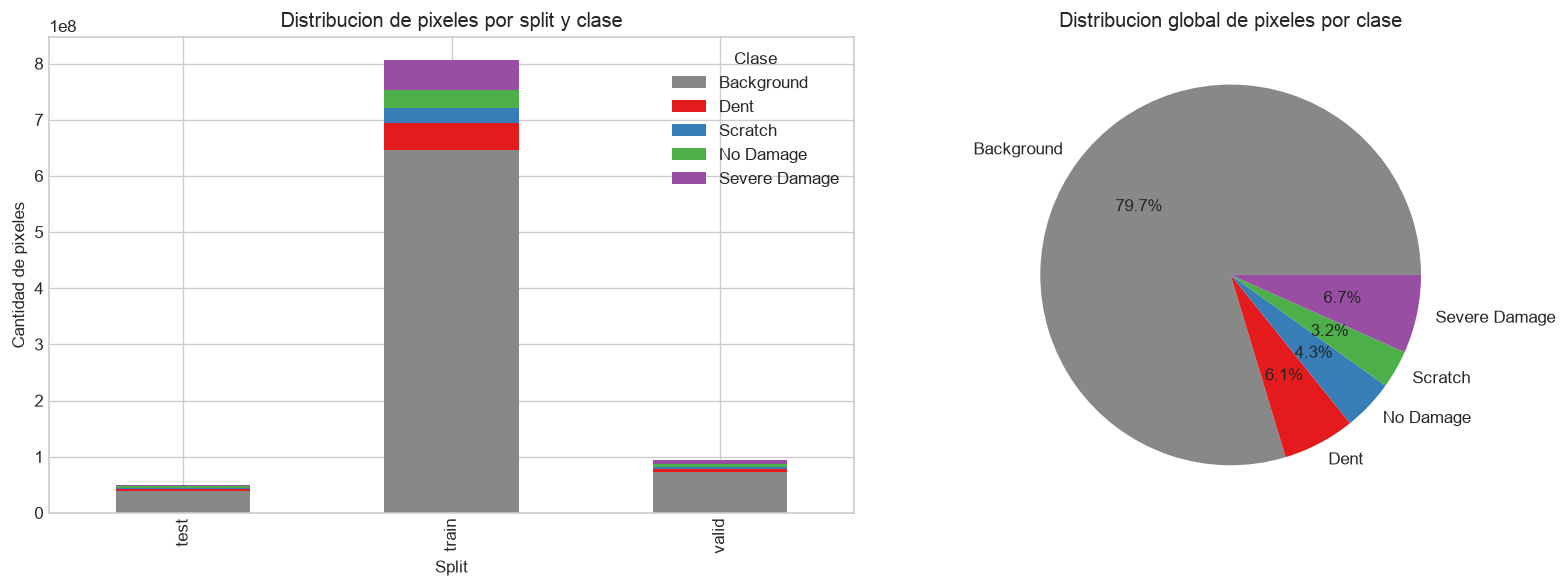

In [4]:
if DATA_ROOT is not None and len(df) > 0:
    pixel_data = []
    for _, row in df.iterrows():
        for c in range(5):
            pixel_data.append({
                'split': row['split'],
                'class': CLASS_NAMES[c],
                'pixels': row['class_pixel_counts'][c],
            })
    pdf = pd.DataFrame(pixel_data)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    pivot = pdf.groupby(['split', 'class'])['pixels'].sum().unstack()
    pivot = pivot[list(CLASS_NAMES.values())]
    ax = pivot.plot(kind='bar', stacked=True, ax=axes[0],
                    color=[CLASS_COLORS[i] for i in range(5)])
    axes[0].set_title('Distribucion de pixeles por split y clase')
    axes[0].set_ylabel('Cantidad de pixeles')
    axes[0].set_xlabel('Split')
    axes[0].legend(title='Clase')

    total_pixels = pdf.groupby('class')['pixels'].sum()
    axes[1].pie(total_pixels.values, labels=total_pixels.index,
                autopct='%1.1f%%',
                colors=[CLASS_COLORS[i] for i in range(5)])
    axes[1].set_title('Distribucion global de pixeles por clase')

    plt.tight_layout()
    plt.show()
else:
    print('No hay datos para graficar.')

## Frecuencia de clases por imagen

Cuantas imagenes contienen cada clase (al menos un pixel)?

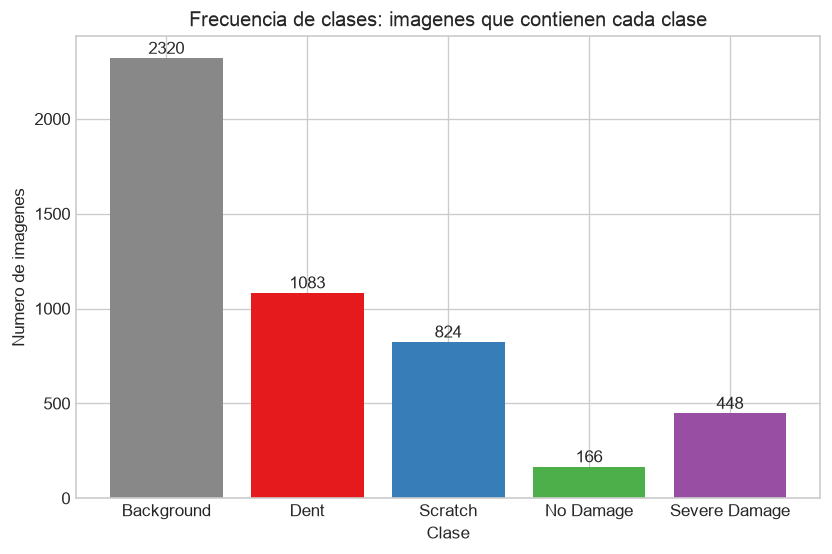

Clase mas frecuente: Background (2320 imagenes)
Clase menos frecuente: No Damage (166 imagenes)


In [5]:
if DATA_ROOT is not None and len(df) > 0:
    class_freq = {c: 0 for c in range(5)}
    for _, row in df.iterrows():
        for c in range(5):
            if row['class_pixel_counts'][c] > 0:
                class_freq[c] += 1

    fig, ax = plt.subplots(figsize=(8, 5))
    names = [CLASS_NAMES[c] for c in range(5)]
    counts = [class_freq[c] for c in range(5)]
    bars = ax.bar(names, counts, color=[CLASS_COLORS[c] for c in range(5)])
    ax.set_title('Frecuencia de clases: imagenes que contienen cada clase')
    ax.set_ylabel('Numero de imagenes')
    ax.set_xlabel('Clase')
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(val), ha='center', va='bottom')
    plt.show()

    print(f'Clase mas frecuente: {names[counts.index(max(counts))]} ({max(counts)} imagenes)')
    print(f'Clase menos frecuente: {names[counts.index(min(counts))]} ({min(counts)} imagenes)')
else:
    print('No hay datos.')

## Distribucion de clases dominantes

Para cada imagen, cual es la clase con mayor cantidad de pixeles?

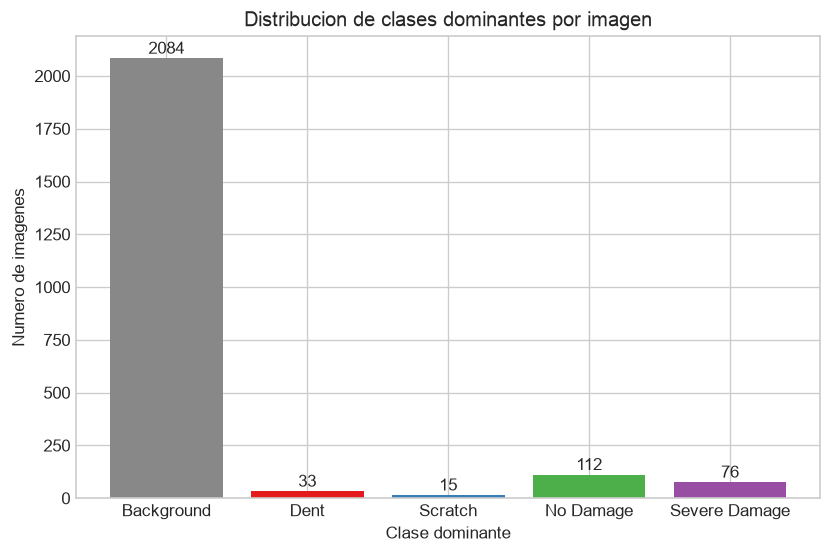

  Background: 2084 imagenes (89.8%)
  Dent: 33 imagenes (1.4%)
  Scratch: 15 imagenes (0.6%)
  No Damage: 112 imagenes (4.8%)
  Severe Damage: 76 imagenes (3.3%)


In [6]:
if DATA_ROOT is not None and len(df) > 0:
    dominant_counts = df['dominant_class'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    names_dom = [CLASS_NAMES[i] for i in dominant_counts.index]
    colors_dom = [CLASS_COLORS[i] for i in dominant_counts.index]
    bars = ax.bar(names_dom, dominant_counts.values, color=colors_dom)
    ax.set_title('Distribucion de clases dominantes por imagen')
    ax.set_ylabel('Numero de imagenes')
    ax.set_xlabel('Clase dominante')
    for bar, val in zip(bars, dominant_counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(val), ha='center', va='bottom')
    plt.show()

    for idx in dominant_counts.index:
        pct = 100 * dominant_counts[idx] / len(df)
        print(f'  {CLASS_NAMES[idx]}: {dominant_counts[idx]} imagenes ({pct:.1f}%)')
else:
    print('No hay datos.')

## Tamanos de regiones (blobs)

Para cada clase, se etiquetan componentes conexas con `skimage.measure.label`
y se calcula el area (en pixeles) de cada blob mediante `regionprops`.

Total de blobs analizados: 585


/var/folders/dr/f_hlmxzj2830ktrql6jx83180000gp/T/ipykernel_52955/3734797082.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bdf, x='class', y='area_pixels', order=order,


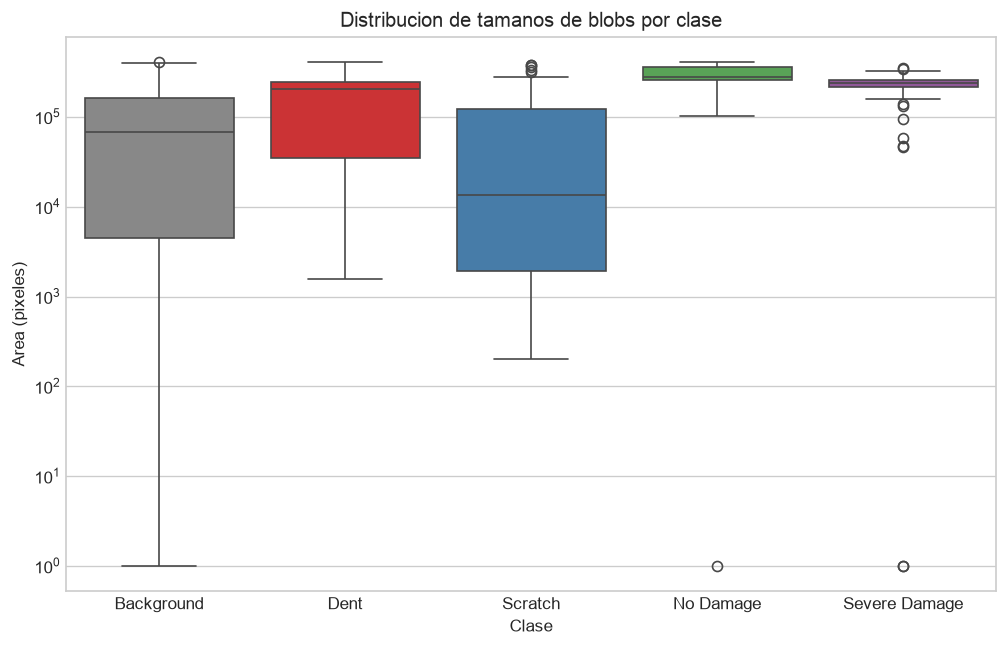


Estadisticas de area de blobs por clase:
               count      mean       std     min       25%       50%  \
class                                                                  
Background     346.0  107905.4  118031.2     1.0    4526.8   68215.0   
Dent            64.0  156024.4  116273.7  1583.0   35197.5  206140.5   
No Damage       53.0  294737.9   79693.1     1.0  257439.0  277702.0   
Scratch         63.0   78615.3  118952.6   203.0    1937.5   13376.0   
Severe Damage   59.0  223832.3   75228.7     1.0  213099.5  239795.0   

                    75%       max  
class                              
Background     164445.8  407797.0  
Dent           246138.0  405803.0  
No Damage      363634.0  409033.0  
Scratch        121085.5  381500.0  
Severe Damage  260899.5  350098.0  


In [7]:
if DATA_ROOT is not None and len(df) > 0:
    blob_data = []
    sample_df = df.groupby('dominant_class').apply(lambda x: x.sample(min(50, len(x)), random_state=42))
    sample_df = sample_df.reset_index(drop=True)

    for _, row in sample_df.iterrows():
        mask = np.array(Image.open(row['mask_path']))
        for c in range(5):
            binary = (mask == c)
            if binary.sum() == 0:
                continue
            labelled = measure.label(binary)
            props = measure.regionprops(labelled)
            for p in props:
                blob_data.append({
                    'class': CLASS_NAMES[c],
                    'area_pixels': p.area,
                })

    bdf = pd.DataFrame(blob_data)
    print(f'Total de blobs analizados: {len(bdf)}')

    fig, ax = plt.subplots(figsize=(10, 6))
    order = [CLASS_NAMES[i] for i in range(5)]
    sns.boxplot(data=bdf, x='class', y='area_pixels', order=order,
                palette=[CLASS_COLORS[i] for i in range(5)], ax=ax)
    ax.set_title('Distribucion de tamanos de blobs por clase')
    ax.set_ylabel('Area (pixeles)')
    ax.set_xlabel('Clase')
    ax.set_yscale('log')
    plt.show()

    print('\nEstadisticas de area de blobs por clase:')
    print(bdf.groupby('class')['area_pixels'].describe().round(1))
else:
    print('No hay datos.')


## Imagenes de muestra con superposicion

Se muestran ejemplos con la mascara superpuesta sobre la imagen original
usando alpha blending con un colormap semitransparente.

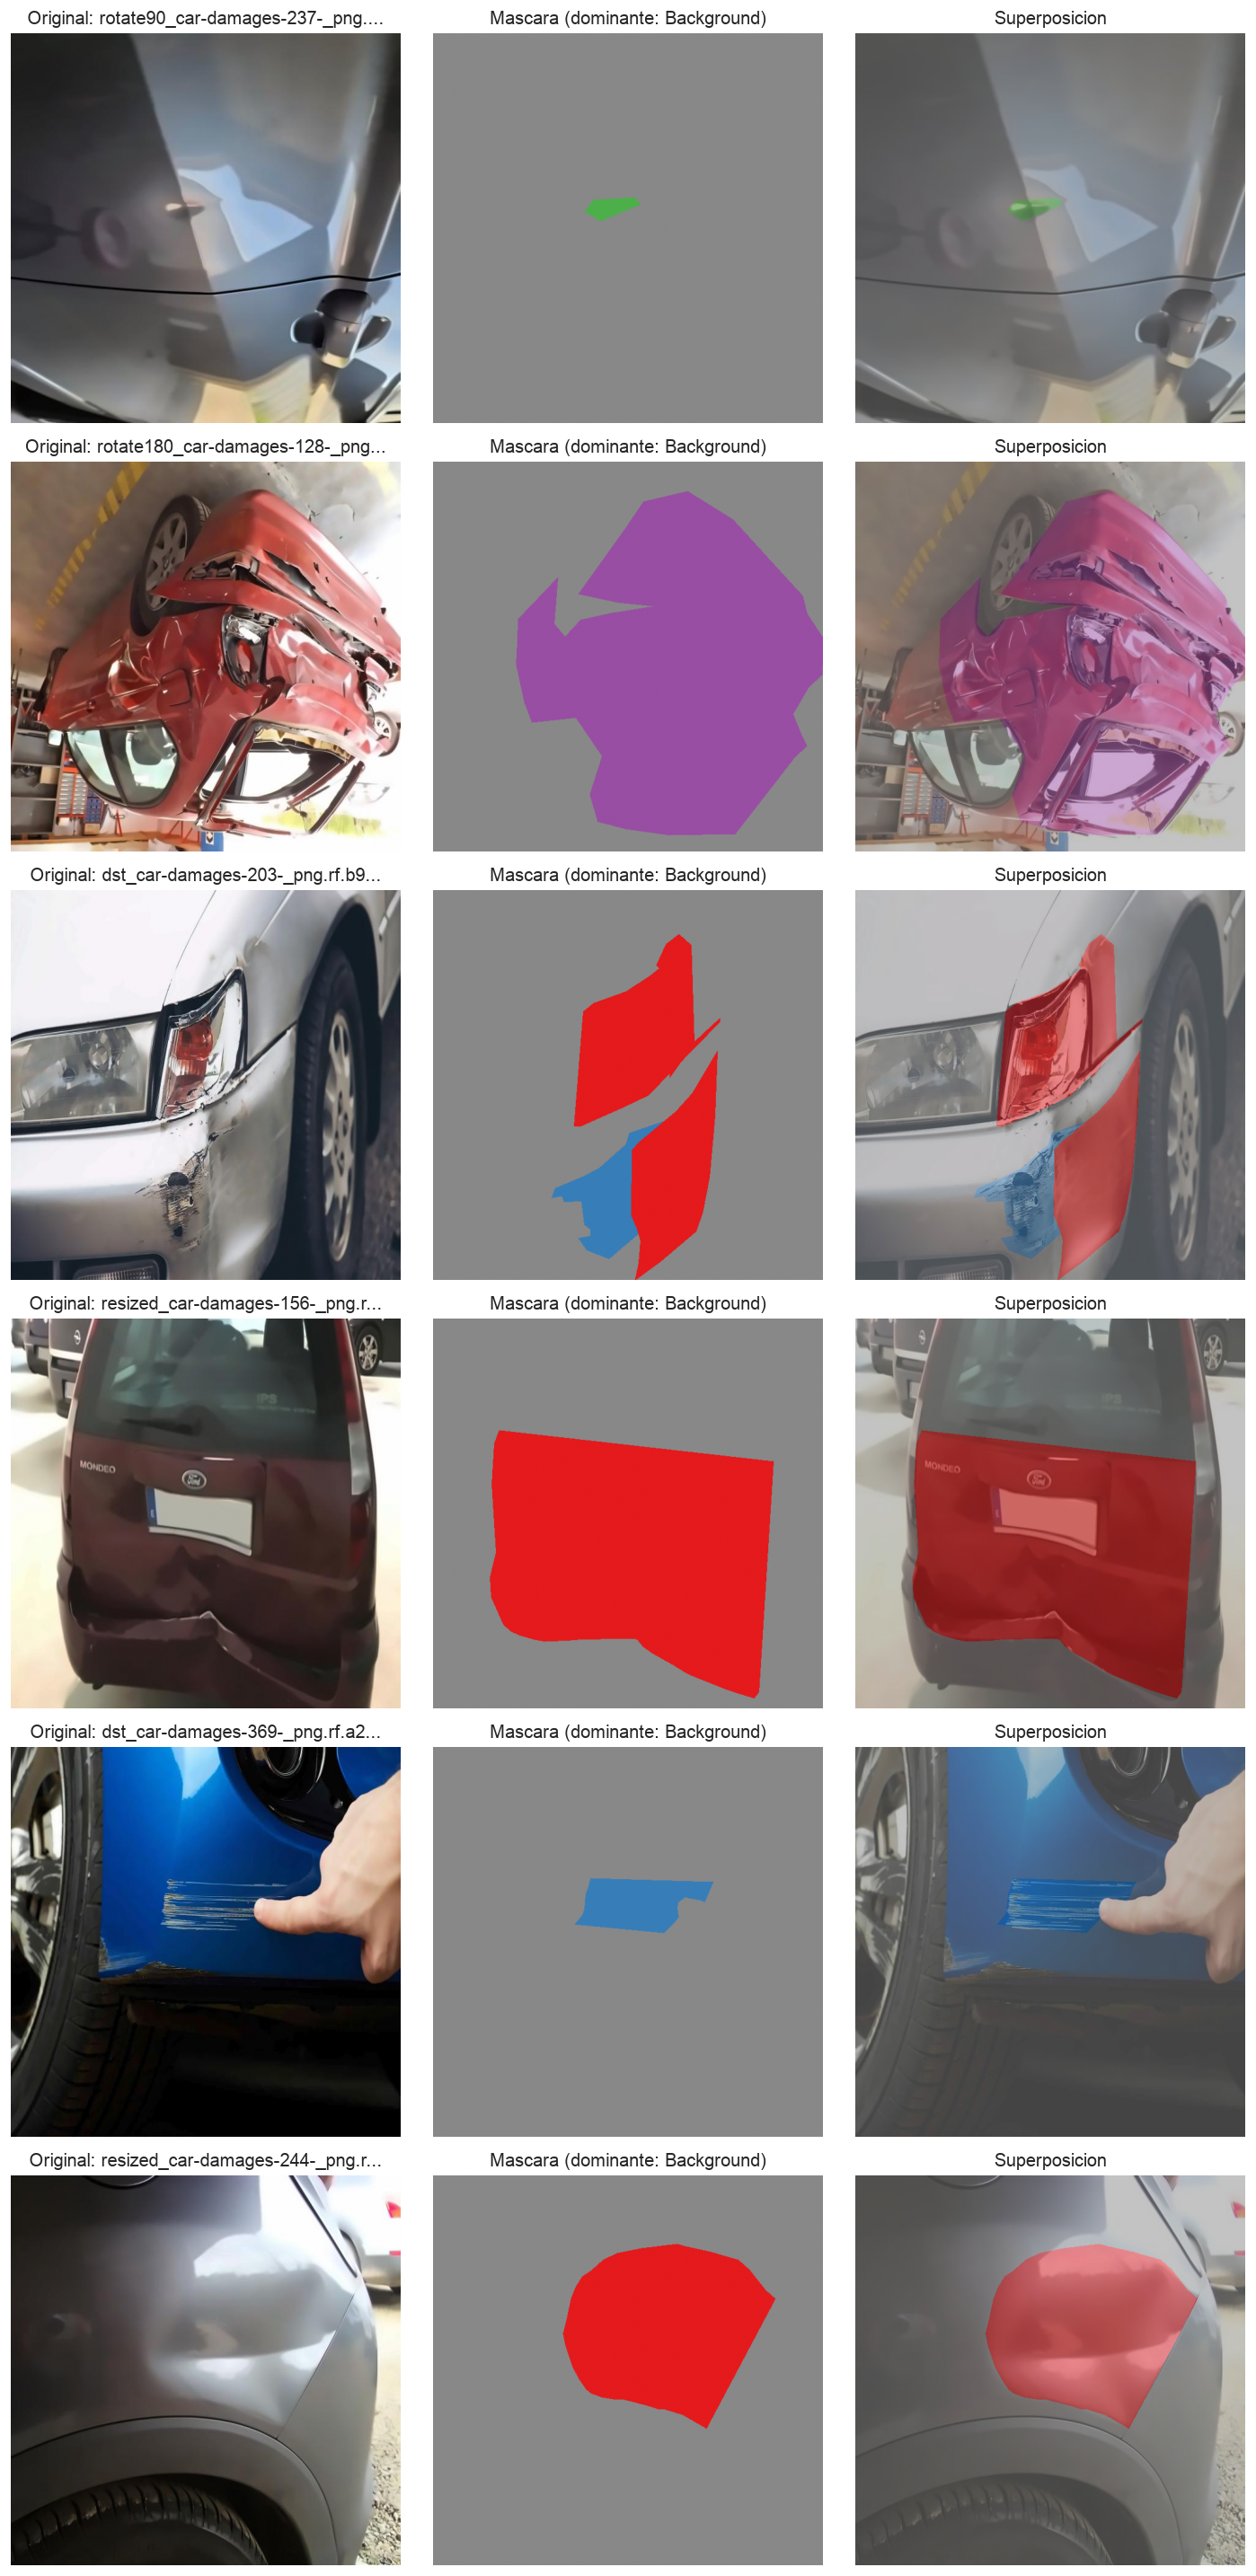

In [8]:
def overlay_mask(image, mask, alpha=0.5):
    """Superpone la mascata coloreada sobre la imagen."""
    rgb_mask = np.zeros((*mask.shape, 3), dtype=np.float32)
    for c in range(5):
        color = np.array([
            int(CLASS_COLORS[c][1:3], 16),
            int(CLASS_COLORS[c][3:5], 16),
            int(CLASS_COLORS[c][5:7], 16),
        ]) / 255.0
        rgb_mask[mask == c] = color
    blended = (1 - alpha) * image + alpha * rgb_mask
    return np.clip(blended, 0, 1)


def create_cmap_for_class():
    """Crea un ListedColormap para las 4 clases."""
    from matplotlib.colors import ListedColormap
    colors = [CLASS_COLORS[i] for i in range(5)]
    return ListedColormap(colors)


if DATA_ROOT is not None and len(df) > 0:
    n_samples = 6
    sample_rows = df.sample(n_samples, random_state=42).reset_index(drop=True)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))

    for i, (_, row) in enumerate(sample_rows.iterrows()):
        img = np.array(Image.open(row['image_path']).convert('RGB')) / 255.0
        mask = np.array(Image.open(row['mask_path']))

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Original: {row["image_id"][:30]}...')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap=create_cmap_for_class(), vmin=0, vmax=4)
        axes[i, 1].set_title(f'Mascara (dominante: {CLASS_NAMES[row["dominant_class"]]})')
        axes[i, 1].axis('off')

        overlay = overlay_mask(img, mask)
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Superposicion')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No hay datos.')


## Co-ocurrencia de clases

Matriz que muestra con que frecuencia dos clases aparecen juntas en una misma
imagen (basado en presencia de pixeles, no en instancias).

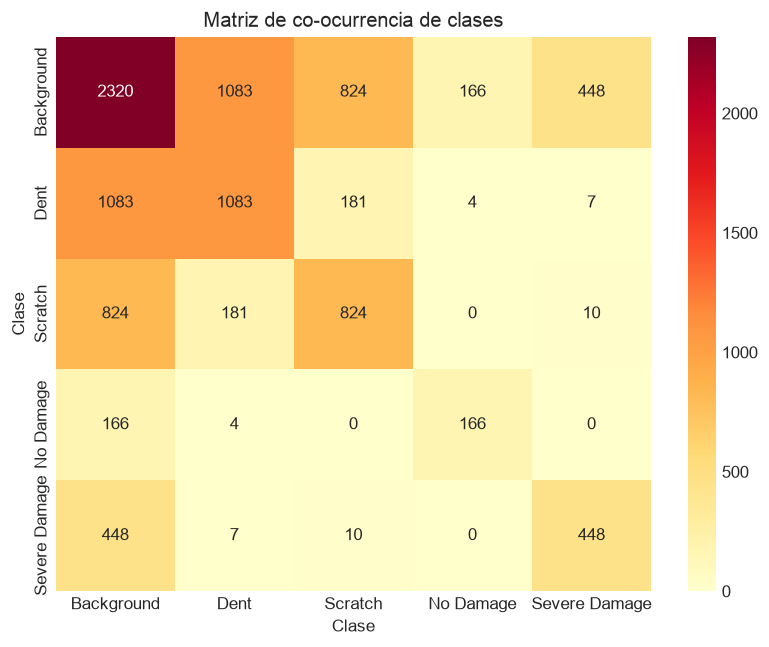

Interpretacion:
  La diagonal indica cuantas imagenes contienen cada clase.
  Fuera de la diagonal: cuantas imagenes contienen ambas clases.


In [9]:
if DATA_ROOT is not None and len(df) > 0:
    cooc = np.zeros((5, 5), dtype=int)
    for _, row in df.iterrows():
        present = [c for c in range(5) if row['class_pixel_counts'][c] > 0]
        for i in present:
            for j in present:
                cooc[i, j] += 1

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=[CLASS_NAMES[i] for i in range(5)],
                yticklabels=[CLASS_NAMES[i] for i in range(5)],
                ax=ax)
    ax.set_title('Matriz de co-ocurrencia de clases')
    ax.set_xlabel('Clase')
    ax.set_ylabel('Clase')
    plt.show()

    print('Interpretacion:')
    print('  La diagonal indica cuantas imagenes contienen cada clase.')
    print('  Fuera de la diagonal: cuantas imagenes contienen ambas clases.')
else:
    print('No hay datos.')
